**Walmart Retail Data Analysis**

Project Overview

This project performs an end-to-end analysis of Walmart retail data using Python. The analysis focuses on sales performance, profitability, customer segments, product categories, discounts, shipping costs, and factors associated with loss-making transactions.

The project includes:

- Data cleaning and preprocessing
- Missing value treatment
- Feature engineering
- Exploratory data analysis
- Correlation analysis
- Statistical hypothesis testing
- Profitability and loss analysis

Objectives

The main objectives of this analysis are:

1. Understand the distribution and characteristics of key business metrics.
2. Identify factors associated with profitability and loss-making transactions.
3. Examine performance across regions, product categories, customer segments, and shipping methods.
4. Investigate the relationship between sales, profit, discounts, and shipping costs.
5. Use statistical tests to determine whether observed differences between groups are statistically significant.


Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
from sklearn.preprocessing import StandardScaler
from scipy.stats import levene, kruskal, f_oneway

# Data Loading and Initial Inspection

# Importing Dataset

In [ ]:
df = pd.read_excel('walmart Retail Data.xlsx')

# Initial Data Inspection

In [ ]:
df.sample(5)

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Profit,Region,Row ID,Sales,Ship Date,Ship Mode,Shipping Cost,State,Unit Price,Zip Code
6069,Bethesda,59.0,Matt Collister,Home Office,0.01,1,2014-11-22,6433,Medium,41,...,73.8900,East,894,159.26,2014-11-23,Regular Air,0.50,Maryland,3.69,20814
5475,Dundalk,56.0,Helen Wasserman,Home Office,0.09,1,2014-08-04,14113,High,22,...,-774.1448,East,1972,8218.16,2014-08-06,Delivery Truck,85.63,Maryland,376.13,21222
4564,Canton,53.0,Anthony Garverick,Small Business,0.05,1,2014-02-18,36454,Critical,8,...,-36.0600,East,5119,69.57,2014-02-21,Regular Air,6.50,MA,7.98,2021
6018,Foxborough,59.0,Karl Brown,Corporate,0.02,1,2014-11-16,14662,High,48,...,-66.2600,East,2052,257.75,2014-11-17,Regular Air,4.75,MA,4.98,2035
2457,Atascadero,46.0,Nora Paige,Small Business,0.03,1,2013-02-24,53344,High,36,...,-132.2615,West,7471,181.95,2013-02-26,Regular Air,6.07,California,4.89,93422


# Data Cleaning and Preparation


# Checking for null values

In [ ]:
df.isna().sum()

,0
City,0
Customer Age,903
Customer Name,0
Customer Segment,0
Discount,0
Number of Records,0
Order Date,0
Order ID,0
Order Priority,0
Order Quantity,0


# Filling null values

In [ ]:
df['Product Base Margin'].fillna(df['Product Base Margin'].median(),inplace=True)

/tmp/ipykernel_3153/3776694231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product Base Margin'].fillna(df['Product Base Margin'].median(),inplace=True)


In [ ]:
df['Product Base Margin'].isna().sum()

np.int64(0)

In [ ]:
df['Customer Age'].fillna(df['Customer Age'].median(),inplace=True)

/tmp/ipykernel_3153/1957567112.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer Age'].fillna(df['Customer Age'].median(),inplace=True)


In [ ]:
df['Customer Age'].isna().sum()

np.int64(0)

# Checking if properly filled

In [ ]:


df.sample(5)

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Profit,Region,Row ID,Sales,Ship Date,Ship Mode,Shipping Cost,State,Unit Price,Zip Code
335,Parma,53.0,Sally Hughsby,Consumer,0.03,1,2012-02-20,55300,High,37,...,-185.170,East,7718,159.8900,2012-02-22,Regular Air,6.89,Ohio,4.06,44134
2579,Lenexa,46.0,Alex Avila,Home Office,0.06,1,2013-03-13,33632,Critical,8,...,-277.783,Central,4722,763.6485,2013-03-14,Regular Air,5.26,Kansas,115.99,66215
4745,Bartlett,54.0,Paul Prost,Corporate,0.01,1,2014-03-23,57095,Medium,37,...,-62.882,South,7988,254.9300,2014-03-26,Regular Air,5.48,Tennessee,6.81,38134
5243,Roseville,56.0,Bart Watters,Corporate,0.01,1,2014-06-22,54150,Critical,12,...,-53.691,Central,7569,2011.6355,2014-06-22,Express Air,3.99,Minnesota,195.99,55113
697,Norfolk,53.0,Lynn Smith,Corporate,0.08,1,2012-04-23,3808,Critical,2,...,-2.830,South,562,6.1300,2012-04-23,Regular Air,0.49,Virginia,2.89,23518


# Feature Engineering

# Adding derived columns

In [ ]:
df['days taken'] = ((pd.to_datetime(df['Ship Date']) - pd.to_datetime(df['Order Date'])))
df['days taken'] = df['days taken'].dt.days
df['Order Year'] = pd.to_datetime(df['Order Date']).dt.year
df['Order Month'] = pd.to_datetime(df['Order Date']).dt.month
df['Order Day'] = pd.to_datetime(df['Order Date']).dt.day
df['Order Quarter'] = pd.to_datetime(df['Order Date']).dt.quarter
df['Order Day of Week'] = pd.to_datetime(df['Order Date']).dt.day_name()
df.sample(5)

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Shipping Cost,State,Unit Price,Zip Code,days taken,Order Year,Order Month,Order Day,Order Quarter,Order Day of Week
4627,Laguna Niguel,53.0,Adam Hart,Corporate,0.07,1,2014-03-02,16642,Not Specified,46,...,2.50,California,205.99,92677,2,2014,3,2,1,Sunday
94,Springfield,53.0,Guy Thornton,Corporate,0.01,1,2012-01-12,37862,Not Specified,27,...,3.99,MO,59.98,65807,3,2012,1,12,1,Thursday
7671,Seymour,67.0,Frank Atkinson,Corporate,0.07,1,2015-08-22,24067,High,19,...,7.50,Indiana,5.98,47274,1,2015,8,22,3,Saturday
3704,Billerica,50.0,Eleni McCrary,Corporate,0.00,1,2013-09-29,37829,Not Specified,28,...,8.29,MA,8.74,1821,2,2013,9,29,3,Sunday
7570,Janesville,67.0,Nathan Gelder,Home Office,0.03,1,2015-08-06,11398,High,26,...,0.81,Wisconsin,2.94,53545,2,2015,8,6,3,Thursday


In [ ]:
def speed(dt):
  if dt < 1:
    return 'instant'
  elif 1 <= dt < 2:
      return 'fast'
  elif 2 <= dt <=3:
    return 'normal'
  else:
    return 'slow'

df['delivery speed'] = df['days taken'].apply(speed)
df.sample(5)

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,State,Unit Price,Zip Code,days taken,Order Year,Order Month,Order Day,Order Quarter,Order Day of Week,delivery speed
3340,Dover,48.0,Sara Luxemburg,Small Business,0.01,1,2013-07-31,43200,Not Specified,3,...,New Jersey,172.99,7801,1,2013,7,31,3,Wednesday,fast
2352,Iowa City,45.0,Michelle Arnett,Home Office,0.03,1,2013-02-05,42500,Not Specified,2,...,Iowa,8.69,52240,2,2013,2,5,1,Tuesday,normal
1738,Bozeman,43.0,Laurel Workman,Home Office,0.04,1,2012-10-17,43044,Medium,3,...,Montana,6783.02,59715,2,2012,10,17,4,Wednesday,normal
2195,North Port,45.0,Steven Ward,Consumer,0.03,1,2013-01-09,4611,High,32,...,Florida,500.98,34287,0,2013,1,9,1,Wednesday,instant
4736,Owosso,54.0,Chuck Clark,Corporate,0.10,1,2014-03-21,58884,Low,46,...,Michigan,85.29,48841,5,2014,3,21,1,Friday,slow


In [ ]:
df['Profit Margin'] = df['Profit']/df['Sales']
df['Profit per Unit'] = df['Profit']/df['Order Quantity']
df['Sales per Unit'] = df['Sales']/df['Order Quantity']
df['Shipping Cost %'] = (df['Shipping Cost']/df['Sales'])*100
df.sample(5)

,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Order Year,Order Month,Order Day,Order Quarter,Order Day of Week,delivery speed,Profit Margin,Profit per Unit,Sales per Unit,Shipping Cost %
157,Pittsburgh,53.0,Rob Haberlin,Corporate,0.02,1,2012-01-21,38021,Medium,36,...,2012,1,21,1,Saturday,fast,0.472059,2.271389,4.811667,0.288650
6884,Danville,64.0,Eva Jacobs,Home Office,0.09,1,2015-04-13,8450,Not Specified,22,...,2015,4,13,2,Monday,fast,-0.290348,-0.546250,1.881364,3.599903
8008,Muskogee,71.0,Pauline Chand,Corporate,0.06,1,2015-10-18,8231,Critical,27,...,2015,10,18,4,Sunday,normal,0.375755,1.105556,2.942222,0.629406
3090,Rapid City,47.0,Philip Brown,Home Office,0.10,1,2013-06-16,3648,Low,46,...,2013,6,16,2,Sunday,normal,0.388398,1.138261,2.930652,0.363475
7057,Federal Way,65.0,Ruben Dartt,Corporate,0.05,1,2015-05-08,52673,Medium,4,...,2015,5,8,2,Friday,normal,-0.625729,-4.131375,6.602500,21.734192


# Changing Datatype for memory optimization

In [ ]:
df['Customer Age'] = df['Customer Age'].astype('int8')
df['Discount'] = df['Discount'].astype('float16')
df['Profit'] = df['Profit'].astype('float32')
df['Sales'] = df['Sales'].astype('float32')
df['Shipping Cost'] = df['Shipping Cost'].astype('float32')
df['Order Quantity'] = df['Order Quantity'].astype('int8')
df['Unit Price'] = df['Unit Price'].astype('float32')
df['days taken'] = df['days taken'].astype('int8')
df['Shipping Cost %'] = df['Shipping Cost %'].astype('float16')
df['Order Year'] = df['Order Year'].astype('int16')
df['Order Month'] = df['Order Month'].astype('int8')
df['Order Day'] = df['Order Day'].astype('int8')
df['Order Quarter'] = df['Order Quarter'].astype('int8')
df['Profit Margin'] = df['Profit Margin'].astype('float16')
df['Profit per Unit'] = df['Profit per Unit'].astype('float16')
df['Sales per Unit'] = df['Sales per Unit'].astype('float16')
df['Product Base Margin'] = df['Product Base Margin'].astype('float16')
df['Zip Code'] = df['Zip Code'].astype('string')
df['Number of Records'] = df['Number of Records'].astype('int8')
df['Row ID'] = df['Row ID'].astype('int32')
df['Product Category'] = df['Product Category'].astype('category')
df['Product Sub-Category'] = df['Product Sub-Category'].astype('category')
df['Product Name'] = df['Product Name'].astype('category')
df['Order Priority'] = df['Order Priority'].astype('category')
df['Customer Segment'] = df['Customer Segment'].astype('category')

# Final check before beginning analysis

In [ ]:
df.shape
df.info()
df.isnull().sum()
df.describe()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   City                  8399 non-null   object        
 1   Customer Age          8399 non-null   int8          
 2   Customer Name         8399 non-null   object        
 3   Customer Segment      8399 non-null   category      
 4   Discount              8399 non-null   float16       
 5   Number of Records     8399 non-null   int8          
 6   Order Date            8399 non-null   datetime64[ns]
 7   Order ID              8399 non-null   int64         
 8   Order Priority        8399 non-null   category      
 9   Order Quantity        8399 non-null   int8          
 10  Product Base Margin   8399 non-null   float16       
 11  Product Category      8399 non-null   category      
 12  Product Container     8399 non-null   object        
 13  Product Name      

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)


,0
City,1421
Customer Age,48
Customer Name,795
Customer Segment,4
Discount,16
Number of Records,1
Order Date,1418
Order ID,5496
Order Priority,5
Order Quantity,50


# Exploratory Data Analysis

# Visualizing distributions

In [ ]:
df['Sales'].describe()

,Sales
count,8399.000000
mean,1775.878174
std,3585.051270
min,2.240000
25%,143.195000
50%,449.420013
75%,1709.320007
max,89061.046875


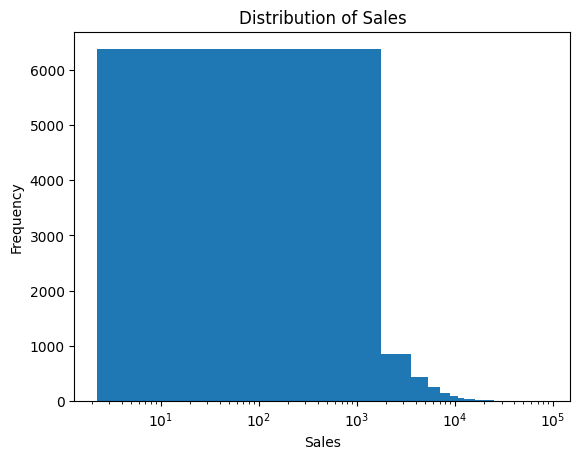

In [ ]:

plt.hist(df['Sales'],bins=50)
plt.xscale('log')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

In [ ]:
df['Profit'].describe()

,Profit
count,8399.000000
mean,181.184418
std,1196.652588
min,-14140.701172
25%,-83.315002
50%,-1.500000
75%,162.748001
max,27220.689453


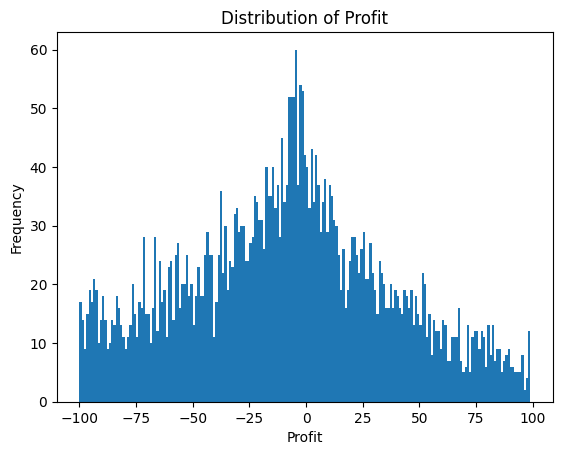

In [ ]:
plt.hist(df['Profit'],bins=range(-100,100))
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Distribution of Profit')
plt.show()

In [ ]:
df['Order Quantity'].describe()

,Order Quantity
count,8399.000000
mean,25.571735
std,14.481071
min,1.000000
25%,13.000000
50%,26.000000
75%,38.000000
max,50.000000


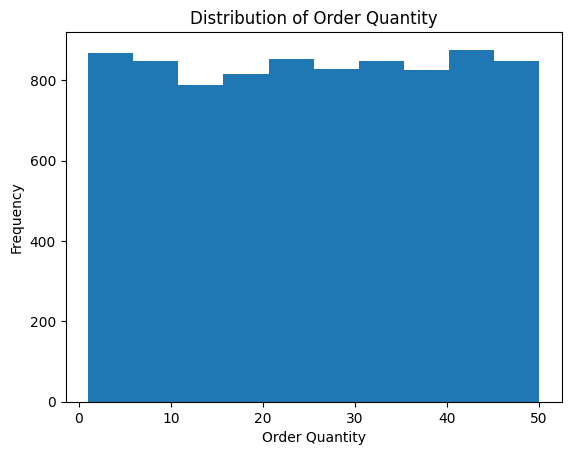

In [ ]:
plt.hist(df['Order Quantity'])
plt.xlabel('Order Quantity')
plt.ylabel('Frequency')
plt.title('Distribution of Order Quantity')
plt.show()

In [ ]:
df['Discount'].describe()

,Discount
count,8399.000000
mean,0.049652
std,0.031830
min,0.000000
25%,0.020004
50%,0.049988
75%,0.080017
max,0.250000


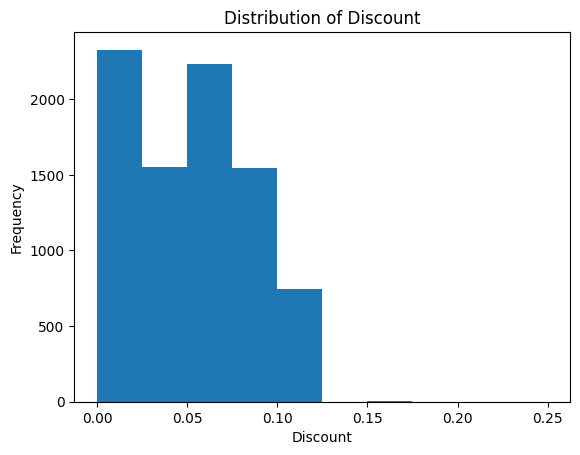

In [ ]:
plt.hist(df['Discount'])
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.title('Distribution of Discount')
plt.show()

In [ ]:
df['Shipping Cost'].describe()

,Shipping Cost
count,8399.000000
mean,12.838557
std,17.264072
min,0.490000
25%,3.300000
50%,6.070000
75%,13.990000
max,164.729996


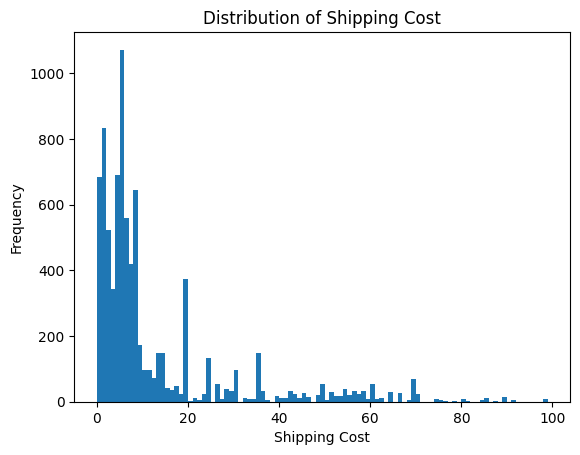

In [ ]:

plt.hist(df['Shipping Cost'],bins=range(0,100))
plt.xlabel('Shipping Cost')
plt.ylabel('Frequency')
plt.title('Distribution of Shipping Cost')
plt.show()

In [ ]:
df['Unit Price'].describe()

,Unit Price
count,8399.000000
mean,89.346252
std,290.353577
min,0.990000
25%,6.480000
50%,20.990000
75%,85.989998
max,6783.020020


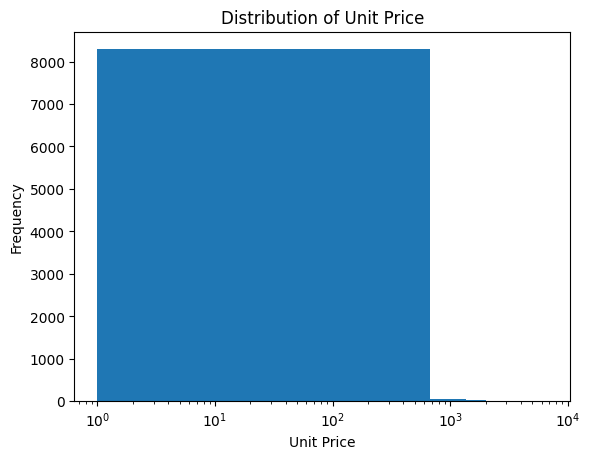

In [ ]:
plt.hist(df['Unit Price'])
plt.xscale('log')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.title('Distribution of Unit Price')
plt.show()

In [ ]:
df['Customer Age'].describe()

,Customer Age
count,8399.000000
mean,54.376950
std,9.005784
min,41.000000
25%,47.000000
50%,53.000000
75%,60.000000
max,95.000000


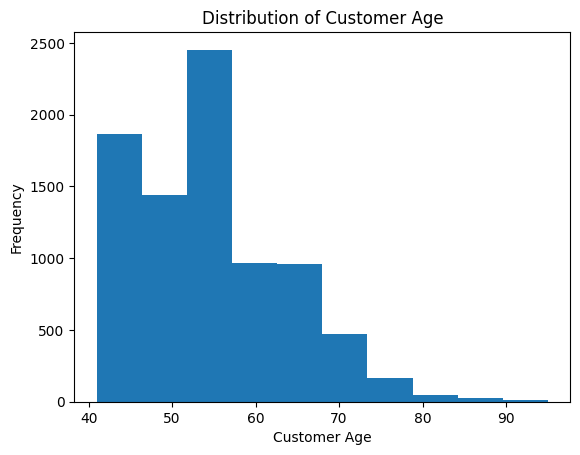

In [ ]:


plt.hist(df['Customer Age'])
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Age')
plt.show()

In [ ]:
df['days taken'].describe()

,days taken
count,8399.000000
mean,2.032028
std,2.301371
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,92.000000


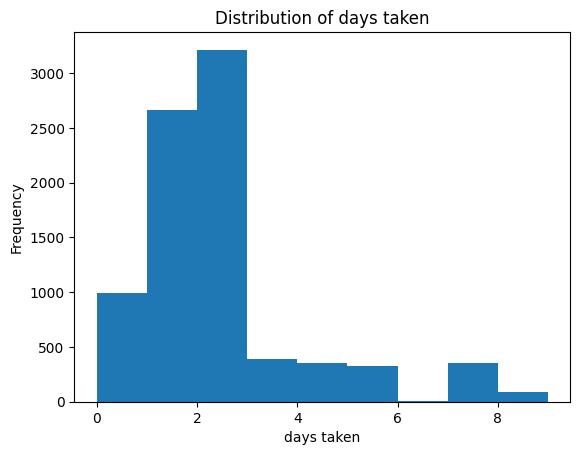

In [ ]:
plt.hist(df['days taken'],bins=range(0,10))
plt.xlabel('days taken')
plt.ylabel('Frequency')
plt.title('Distribution of days taken')
plt.show()

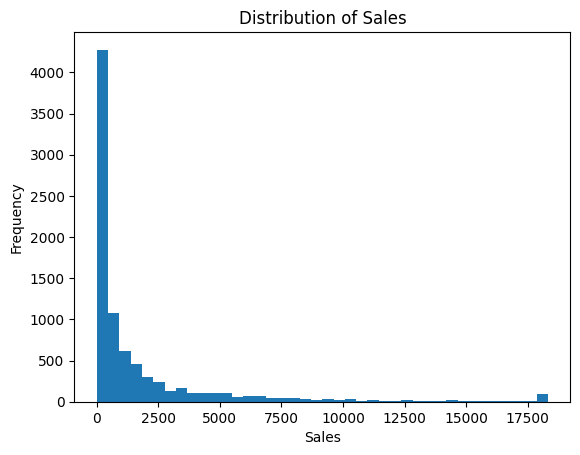

In [ ]:
lower = df['Sales'].quantile(0.01)
upper = df['Sales'].quantile(0.99)

sle_clp = df['Sales'].clip(lower,upper)

plt.hist(sle_clp,bins=40)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

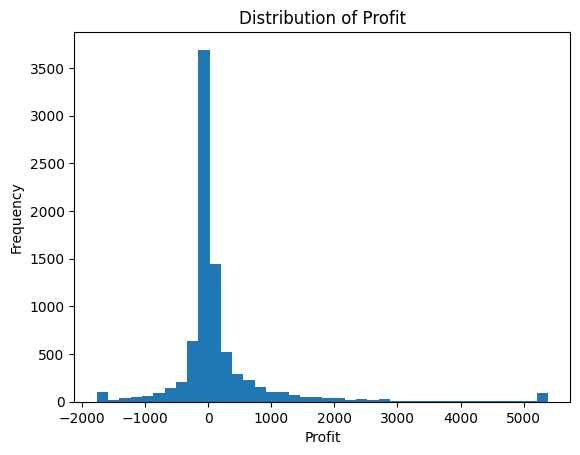

In [ ]:
lower = df['Profit'].quantile(0.01)
upper = df['Profit'].quantile(0.99)

prf_clp = df['Profit'].clip(lower,upper)

plt.hist(prf_clp,bins=40)
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Distribution of Profit')
plt.show()

# Grouped analysis

In [ ]:

display(df.groupby('Order ID')['Sales'].mean().sort_values(ascending=False).tail(10), df.groupby('Order ID')['Profit'].mean().sort_values(ascending=False).head(10))
display(df.groupby('Order ID')['Sales'].sum().sort_values(ascending=False).tail(10), df.groupby('Order ID')['Profit'].sum().sort_values(ascending=False).head(10))

,Sales
Order ID,
17636,7.01
6,6.93
22819,6.77
3808,6.13
52322,5.70
14117,5.31
44098,5.06
16711,3.96
9635,3.42


,Profit
Order ID,
29766,14422.194336
32932,12748.860352
34663,11562.080078
19010,10951.306641
16134,10521.330078
21121,9373.961914
7203,9296.347656
26470,8822.277344
23106,8612.110352


,Sales
Order ID,
17636,7.01
6,6.93
22819,6.77
3808,6.13
52322,5.70
14117,5.31
44098,5.06
16711,3.96
9635,3.42


,Profit
Order ID,
29766,28844.388672
9637,14236.399414
20967,12942.730469
32932,12748.860352
3841,12663.410156
29187,12552.746094
29569,12111.944336
26432,12009.046875
34663,11562.080078


In [ ]:
df.groupby('Region')['Sales'].sum()

,Sales
Region,
Central,4699167.50
East,3416466.50
South,3150219.25
West,3649747.75


In [ ]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
Central,481891.2500
East,317852.0625
South,422507.1250
West,299517.5625


In [ ]:
reg_sum = df.groupby('Region').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

reg_sum['Profit Margin'] = reg_sum['Profit']/reg_sum['Sales']
reg_sum['Shipping Cost %'] = (reg_sum['Shipping_Cost']/reg_sum['Sales'])*100

reg_sum

,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
Region,,,,,,,,
Central,4699167.50,481891.2500,1786,69591,0.049364,35394.480469,0.102548,0.753207
East,3416466.50,317852.0625,1284,47741,0.050387,25792.529297,0.093035,0.754948
South,3150219.25,422507.1250,1242,47250,0.049529,21726.400391,0.134120,0.689679
West,3649747.75,299517.5625,1342,50195,0.049548,24917.630859,0.082065,0.682722


In [ ]:
city_sum = df.groupby('City').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

city_sum['Profit Margin'] = city_sum['Profit']/city_sum['Sales']
city_sum['Shipping Cost %'] = (city_sum['Shipping_Cost']/city_sum['Sales'])*100

display(city_sum)
display(city_sum['Sales'].sort_values(ascending=False).head(10))
display(city_sum['Profit'].sort_values(ascending=False).head(10))



,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
City,,,,,,,,
Aberdeen,11905.330078,2615.424072,4,139,0.053329,140.680008,0.219685,1.181656
Abilene,13436.880859,2128.648926,4,183,0.031428,80.980003,0.158418,0.602670
Abington,225.139999,-42.610001,1,11,0.080017,8.990000,-0.189260,3.993071
Acton,89.989998,18.955000,1,18,0.000000,1.490000,0.210635,1.655740
Addison,1075.102051,0.017997,2,94,0.057489,3.990000,0.000017,0.371128
...,...,...,...,...,...,...,...,...
York,2983.451904,876.582520,5,133,0.035005,45.349998,0.293815,1.520051
Youngstown,2300.403564,100.446991,4,146,0.066010,25.240000,0.043665,1.097199
Yuba City,1035.330078,-216.910004,2,29,0.005001,43.360001,-0.209508,4.188036


,Sales
City,
Madison,119942.898438
San Francisco,103078.765625
Watertown,65865.984375
Portland,63281.910156
Columbus,62854.253906
Danville,62326.277344
Mechanicsville,62018.164062
Kent,56690.828125
Gainesville,54431.433594


,Profit
City,
Madison,38531.488281
Danville,23268.410156
San Francisco,21589.164062
Searcy,19072.132812
Mechanicsville,18538.087891
West Linn,16102.025391
Baton Rouge,15873.322266
Portland,14626.044922
Woodburn,13408.776367


In [ ]:
state_sum = df.groupby('State').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

state_sum['Profit Margin'] = state_sum['Profit']/state_sum['Sales']
state_sum['Shipping Cost %'] = (state_sum['Shipping_Cost']/state_sum['Sales'])*100

display(state_sum)
display(state_sum['Sales'].sort_values(ascending=False).head(10))
display(state_sum['Profit'].sort_values(ascending=False).head(10))

,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
State,,,,,,,,
Alabama,3.050108e+05,53629.988281,86,3304,0.046962,1513.160034,0.175830,0.496100
Arizona,2.491138e+05,39829.328125,96,3526,0.051196,1725.680054,0.159884,0.692728
Arkansas,2.238881e+05,39850.285156,89,3183,0.047156,1706.589966,0.177992,0.762251
California,1.372210e+06,87355.531250,543,19513,0.050823,10190.669922,0.063660,0.742646
Colorado,3.236322e+05,20386.201172,121,4502,0.045483,1882.609985,0.062992,0.581713
Connecticut,1.029241e+05,6885.145020,76,1936,0.052199,963.619995,0.066895,0.936244
Delaware,1.092566e+04,585.351440,8,330,0.044005,121.169998,0.053576,1.109041
Florida,7.776639e+05,82571.953125,329,12177,0.051213,5553.160156,0.106179,0.714082
Georgia,3.258519e+05,45113.292969,123,4723,0.044421,2275.149902,0.138447,0.698216


,Sales
State,
California,1.372210e+06
Illinois,9.593273e+05
Texas,8.638910e+05
Florida,7.776639e+05
New York,7.388942e+05
Ohio,7.294261e+05
Washington,5.603564e+05
Minnesota,4.900099e+05
Michigan,4.751708e+05


,Profit
State,
Illinois,108532.023438
Texas,93571.523438
Ohio,88615.476562
California,87355.531250
New York,86395.960938
Florida,82571.953125
Virginia,61721.929688
Alabama,53629.988281
Oregon,45273.992188


In [ ]:

cstseg_sum = df.groupby('Customer Segment').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

cstseg_sum['Profit Margin'] = cstseg_sum['Profit']/cstseg_sum['Sales']
cstseg_sum['Shipping Cost %'] = (cstseg_sum['Shipping_Cost']/cstseg_sum['Sales'])*100

display(cstseg_sum)

/tmp/ipykernel_3153/1270557148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cstseg_sum = df.groupby('Customer Segment').agg(


,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
Customer Segment,,,,,,,,
Consumer,3063611.0,287960.00000,1076,41760,0.049905,21477.810547,0.093994,0.701062
Corporate,5498905.0,599745.93750,2002,78517,0.049843,39061.851562,0.109066,0.710357
Home Office,3564764.0,318354.09375,1341,52807,0.049446,25952.208984,0.089306,0.728020
Small Business,2788321.0,315707.96875,1077,41693,0.049406,21339.169922,0.113225,0.765305


In [ ]:
cstna_sum = df.groupby('Customer Name').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

cstna_sum['Profit Margin'] = cstna_sum['Profit']/cstna_sum['Sales']
cstna_sum['Shipping Cost %'] = (cstna_sum['Shipping_Cost']/cstna_sum['Sales'])*100

display(cstna_sum)
display(cstna_sum['Sales'].sort_values(ascending=False).head(10))
display(cstna_sum['Profit'].sort_values(ascending=False).head(10))

,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
Customer Name,,,,,,,,
Aaron Bergman,11630.589844,3025.843994,5,168,0.032864,54.279999,0.260163,0.466700
Aaron Hawkins,27690.726562,5961.405762,9,370,0.056666,156.860001,0.215285,0.566471
Aaron Smayling,8835.323242,2114.402588,8,303,0.042861,75.779999,0.239312,0.857694
Adam Bellavance,11577.580078,-181.948364,8,333,0.045001,155.149994,-0.015716,1.340090
Adam Hart,26114.263672,4071.847168,18,506,0.054445,249.720001,0.155924,0.956259
...,...,...,...,...,...,...,...,...
Vivian Mathis,29420.890625,1705.886597,11,359,0.047340,188.820007,0.057982,0.641789
William Brown,38872.589844,5886.458984,15,555,0.040870,290.269989,0.151430,0.746722
Xylona Price,18037.085938,1124.219482,7,374,0.042857,149.750000,0.062328,0.830234


,Sales
Customer Name,
Emily Phan,117124.437500
Deborah Brumfield,97433.132812
Roy Skaria,92542.156250
Sylvia Foulston,88875.757812
Grant Carroll,88417.000000
Alejandro Grove,83561.929688
Darren Budd,81577.343750
Julia Barnett,80044.453125
John Lucas,79696.187500


,Profit
Customer Name,
Emily Phan,34005.445312
Deborah Brumfield,31121.218750
Grant Carroll,27977.279297
Karen Carlisle,21731.525391
Alejandro Grove,20588.917969
Liz MacKendrick,20397.236328
John Stevenson,18849.931641
Clytie Kelty,18792.814453
Raymond Book,18760.591797


In [ ]:
month_sum = df.groupby('Order Month').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

month_sum.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_sum['Profit Margin'] = month_sum['Profit']/month_sum['Sales']
month_sum['Shipping Cost %'] = (month_sum['Shipping_Cost']/month_sum['Sales'])*100

display(month_sum['Sales'].sort_values(ascending=False))
display(month_sum['Profit'].sort_values(ascending=False))
display(month_sum)

,Sales
Dec,1467490.000
Jan,1444923.375
Oct,1383714.375
Sep,1337957.000
Mar,1273680.875
Apr,1216483.500
Feb,1180083.750
Nov,1163393.375
May,1160896.375
Jul,1141104.375


,Profit
Oct,174016.343750
Jan,171520.734375
Sep,164352.687500
Dec,144189.828125
Apr,123906.476562
Jul,120965.296875
Jun,118703.601562
May,115628.718750
Nov,106670.296875
Mar,104799.328125


,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
Jan,1444923.375,171520.734375,448,17952,0.049472,9591.080078,0.118706,0.663778
Feb,1180083.750,102429.164062,429,16602,0.048115,9139.019531,0.086798,0.774438
Mar,1273680.875,104799.328125,477,17264,0.051680,9046.610352,0.082281,0.710273
Apr,1216483.500,123906.476562,449,17270,0.051253,8731.559570,0.101856,0.717771
May,1160896.375,115628.718750,495,21273,0.049900,8737.559570,0.099603,0.752656
Jun,1030858.500,118703.601562,421,16534,0.049941,7755.790039,0.115150,0.752362
Jul,1141104.375,120965.296875,458,17929,0.047642,8818.849609,0.106007,0.772835
Aug,1115015.375,74585.476562,481,18067,0.048655,9206.679688,0.066892,0.825700
Sep,1337957.000,164352.687500,496,19116,0.050056,9008.790039,0.122839,0.673324
Oct,1383714.375,174016.343750,467,18278,0.049851,9161.259766,0.125760,0.662077


In [ ]:
day_sum = df.groupby('Order Day').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

day_sum['Profit Margin'] = day_sum['Profit']/day_sum['Sales']
day_sum['Shipping Cost %'] = (day_sum['Shipping_Cost']/day_sum['Sales'])*100

display(day_sum['Sales'].sort_values(ascending=False).head(10))
display(day_sum['Profit'].sort_values(ascending=False).head(10))
display(day_sum)

,Sales
Order Day,
5,634481.8125
2,628902.6875
21,609024.4375
20,580633.6875
12,574161.0000
10,550124.5625
25,530686.3750
22,527416.3125
7,512435.0625


,Profit
Order Day,
21,92744.734375
5,83735.468750
20,71325.531250
19,69926.171875
9,68744.671875
29,65369.886719
15,61056.625000
26,56841.445312
7,55963.070312


,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Profit Margin,Shipping Cost %
Order Day,,,,,,,,
1,465052.156250,21738.978516,171,6829,0.049774,2979.429932,0.046745,0.640666
2,628902.687500,52189.062500,183,7591,0.049554,4342.850098,0.082984,0.690544
3,472244.625000,51175.378906,188,6824,0.050368,3795.239990,0.108366,0.803660
4,500470.625000,45013.789062,197,7865,0.052932,3857.889893,0.089943,0.770852
5,634481.812500,83735.468750,182,7630,0.050861,4182.709961,0.131975,0.659232
6,499190.437500,33459.429688,172,6812,0.046605,3542.379883,0.067027,0.709625
7,512435.062500,55963.070312,203,7542,0.051073,3438.100098,0.109210,0.670934
8,329433.156250,42411.691406,157,5752,0.047230,3086.610107,0.128741,0.936946
9,510583.468750,68744.671875,189,7526,0.051523,3667.750000,0.134639,0.718345


In [ ]:
year_sum = df.groupby('Order Year').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Discount = ('Discount','mean'),
    Shipping_Cost = ('Shipping Cost','sum')
)

year_sum['Progit Margin'] = year_sum['Profit']/year_sum['Sales']
year_sum['Shipping Cost %'] = (year_sum['Shipping_Cost']/year_sum['Sales'])*100

display(year_sum['Sales'].sort_values(ascending=False))
display(year_sum['Profit'].sort_values(ascending=False))
display(year_sum)

,Sales
Order Year,
2012,4209139.50
2015,3719963.75
2013,3549680.75
2014,3436816.75


,Profit
Order Year,
2012,434538.78125
2014,381455.96875
2013,363871.37500
2015,341901.81250


,Sales,Profit,Orders,Quantity,Discount,Shipping_Cost,Progit Margin,Shipping Cost %
Order Year,,,,,,,,
2012,4209139.50,434538.78125,1394,54380,0.048855,28430.160156,0.103237,0.675439
2013,3549680.75,363871.37500,1393,54384,0.049386,27325.208984,0.102508,0.769793
2014,3436816.75,381455.96875,1317,51564,0.050822,24925.099609,0.110991,0.725238
2015,3719963.75,341901.81250,1392,54449,0.049712,27150.570312,0.091910,0.729861


In [ ]:
ship_sum = df.groupby('Ship Mode').agg(
    Count = ('Ship Mode','count'),
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    avg_days = ('days taken','mean'),
    shipping_cost = ('Shipping Cost','sum')
)
ship_sum

,Count,Sales,Profit,avg_days,shipping_cost
Ship Mode,,,,,
Delivery Truck,1146,6224878.500,2.696448e+05,2.035777,51971.941406
Express Air,983,1184418.875,1.474303e+05,2.005086,7850.910156
Regular Air,6270,7506303.000,1.104693e+06,2.035566,48008.191406


In [ ]:
df.groupby("Order Priority").agg(
    Orders=("Order ID", "nunique"),
    Avg_Days=("days taken", "mean"),
    Median_Days=("days taken", "median"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

/tmp/ipykernel_3153/124451510.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Order Priority").agg(


,Orders,Avg_Days,Median_Days,Sales,Profit
Order Priority,,,,,
Critical,1090,1.514303,2.0,2724798.75,182876.828125
High,1137,1.411199,1.0,3267356.25,407069.656250
Low,1124,4.237209,4.0,3282630.50,386184.843750
Medium,1075,1.471490,1.0,2862452.00,327051.687500
Not Specified,1080,1.464713,1.0,2778363.25,218584.921875


In [ ]:
df.groupby(['Region','Product Category'])['Sales'].mean().unstack()

/tmp/ipykernel_3153/1985624165.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Region','Product Category'])['Sales'].mean().unstack()


Product Category,Furniture,Office Supplies,Technology
Region,,,
Central,2801.557861,841.288025,2746.173584
East,3425.758545,874.893616,2467.830322
South,2715.881104,784.765747,3096.086426
West,3107.438232,746.324280,3299.465088


In [ ]:
df.groupby(['Region','Customer Segment'])['Sales'].sum().unstack()

/tmp/ipykernel_3153/4054024808.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Region','Customer Segment'])['Sales'].sum().unstack()


Customer Segment,Consumer,Corporate,Home Office,Small Business
Region,,,,
Central,661268.6875,2045208.625,1.268332e+06,724358.1250
East,706912.5000,1054845.375,9.070976e+05,747611.0625
South,777934.5000,1226248.625,6.518180e+05,494218.3125
West,917495.4375,1172602.250,7.375166e+05,822133.5000


In [ ]:
df.groupby(['Region', 'Order Month'])['Sales'].sum().unstack()

Order Month,1,2,3,4,5,6,7,8,9,10,11,12
Region,,,,,,,,,,,,
Central,421956.25000,364321.28125,373961.906250,328114.687500,323736.03125,393432.906250,304993.875000,375544.562500,470273.718750,430771.43750,448337.687500,463722.906250
East,405243.87500,205849.96875,238120.359375,299156.312500,260953.50000,237177.671875,226236.156250,190994.734375,287360.218750,326300.62500,194689.390625,544383.687500
South,339720.12500,230819.96875,407540.968750,255029.203125,256447.34375,201281.078125,233583.609375,213471.781250,254277.015625,286482.31250,258962.703125,212603.265625
West,278003.15625,379092.59375,254057.703125,334183.218750,319759.53125,198966.875000,376290.750000,335004.250000,326046.031250,340160.03125,261403.578125,246780.109375


In [ ]:
df.groupby(['Product Category', 'Product Sub-Category'])['Sales'].sum().unstack()

/tmp/ipykernel_3153/3600983212.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Product Category', 'Product Sub-Category'])['Sales'].sum().unstack()


Product Sub-Category,Appliances,Binders and Binder Accessories,Bookcases,Chairs & Chairmats,Computer Peripherals,Copiers and Fax,Envelopes,Labels,Office Furnishings,Office Machines,Paper,Pens & Art Supplies,Rubber Bands,"Scissors, Rulers and Trimmers",Storage & Organization,Tables,Telephones and Communication
Product Category,,,,,,,,,,,,,,,,,
Furniture,0.0000,0.000000e+00,822652.0625,1761836.5,0.0000,0.00,0.000000,0.000000,698093.8125,0.00,0.000,0.00000,0.000000,0.0000,0.000,1896008.125,0.00
Office Supplies,736991.5625,1.022958e+06,0.0000,0.0,0.0000,0.00,174085.796875,38981.550781,0.0000,0.00,446452.875,167107.21875,15006.629883,80996.3125,1070182.625,0.000,0.00
Technology,0.0000,0.000000e+00,0.0000,0.0,795875.9375,1130361.25,0.000000,0.000000,0.0000,2168697.25,0.000,0.00000,0.000000,0.0000,0.000,0.000,1889313.75


In [ ]:
df.groupby('Order ID')['Product Name'].count().sort_values(ascending=False).head(10)

,Product Name
Order ID,
43745,6
24132,6
48452,5
43875,5
58784,5
59781,5
42528,5
12261,5
12067,5


#Relationship Analysis

# Chi-Square test

In [ ]:
contingency = pd.crosstab(df['Order Priority'],df['delivery speed'])
contingency

delivery speed,fast,instant,normal,slow
Order Priority,,,,
Critical,608,185,810,5
High,712,213,843,0
Low,0,227,364,1129
Medium,672,177,777,5
Not Specified,670,189,809,4


In [ ]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
print(f'chi2_stat: {chi2_stat}')
print(f'p_value: {p_value}')
print(f'dof: {dof}')

if p_value < 0.05:
  print('there is a relationship between order priority and days taken')
else:
  print('there is no relationship between order priority and days taken')

print(f'expected: {expected}')

chi2_stat: 5236.260278683063
p_value: 0.0
dof: 12
there is a relationship between order priority and days taken
expected: [[509.64352899 189.72830099 689.79926182 218.8289082 ]
 [560.3543279  208.6067389  758.43600429 240.60292892]
 [545.14108822 202.94320752 737.84498155 234.07072271]
 [516.93320633 192.44207644 699.66579355 221.95892368]
 [529.92784855 197.27967615 717.2539588  227.53851649]]


# Correlation Analysis

In [ ]:
numeric_cols = [
    'Sales',
    'Profit',
    'Customer Age',
    'Discount',
    'Shipping Cost',
    'Order Quantity',
    'Unit Price',
    'days taken',
    'Shipping Cost %',
    'Profit Margin',
    'Profit per Unit',
    'Sales per Unit',
    'Product Base Margin'
]

corr = df[numeric_cols].corr()
corr

,Sales,Profit,Customer Age,Discount,Shipping Cost,Order Quantity,Unit Price,days taken,Shipping Cost %,Profit Margin,Profit per Unit,Sales per Unit,Product Base Margin
Sales,1.000000,0.581960,0.003651,-0.019681,0.434578,0.220582,0.602521,0.010626,-0.201389,0.190671,0.037023,0.607866,0.156077
Profit,0.581960,1.000000,-0.008538,-0.037126,-0.021362,0.194655,-0.008854,0.012089,-0.118599,0.323138,0.454895,-0.001470,-0.112006
Customer Age,0.003651,-0.008538,1.000000,0.014647,0.006557,0.016687,0.007645,-0.014124,-0.008813,0.002984,-0.003710,0.008035,-0.017519
Discount,-0.019681,-0.037126,0.014647,1.000000,-0.001956,-0.009649,0.001336,-0.002439,0.017967,-0.057848,-0.006718,-0.009067,0.004157
Shipping Cost,0.434578,-0.021362,0.006557,-0.001956,1.000000,-0.011457,0.239959,-0.000183,0.054636,-0.125233,-0.035926,0.248422,0.371467
Order Quantity,0.220582,0.194655,0.016687,-0.009649,-0.011457,1.000000,-0.104284,0.011813,-0.439210,0.215590,0.122841,-0.108805,0.007806
Unit Price,0.602521,-0.008854,0.007645,0.001336,0.239959,-0.104284,1.000000,-0.000684,-0.100780,-0.004811,-0.494616,0.994481,0.057876
days taken,0.010626,0.012089,-0.014124,-0.002439,-0.000183,0.011813,-0.000684,1.000000,0.000642,0.013927,0.005140,-0.001392,-0.003390
Shipping Cost %,-0.201389,-0.118599,-0.008813,0.017967,0.054636,-0.439210,-0.100780,0.000642,1.000000,-0.478133,-0.008289,-0.095878,-0.068863
Profit Margin,0.190671,0.323138,0.002984,-0.057848,-0.125233,0.215590,-0.004811,0.013927,-0.478133,1.000000,0.211656,-0.006750,-0.141791


In [ ]:
corr.min()

,0
Sales,-0.201389
Profit,-0.118599
Customer Age,-0.017519
Discount,-0.057848
Shipping Cost,-0.125233
Order Quantity,-0.439210
Unit Price,-0.494616
days taken,-0.014124
Shipping Cost %,-0.478133
Profit Margin,-0.478133


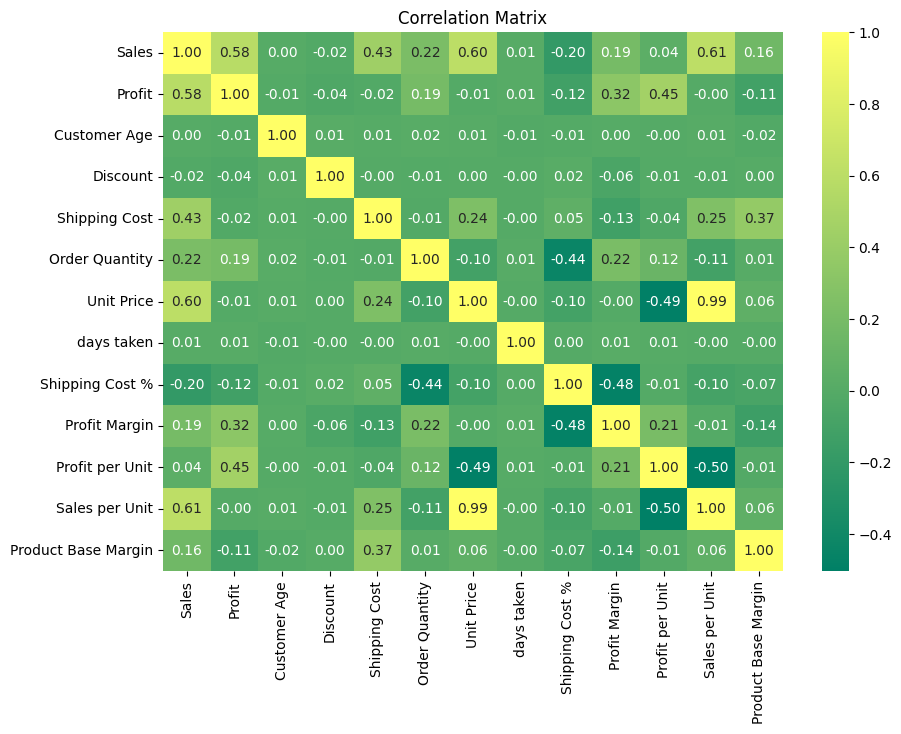

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True, fmt='.2f',cmap='summer')
plt.title('Correlation Matrix')
plt.show()


<Axes: xlabel='Discount', ylabel='Sales'>

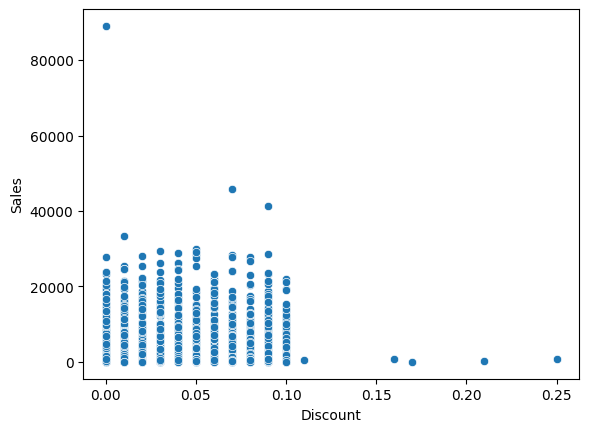

In [ ]:
sns.scatterplot(df,x=df['Discount'],y=df['Sales'])

<Axes: xlabel='Discount', ylabel='Profit'>

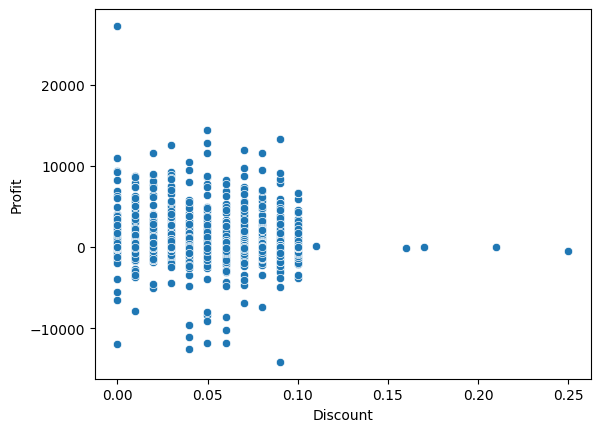

In [ ]:
sns.scatterplot(df,x=df['Discount'],y=df['Profit'])

<Axes: xlabel='Sales', ylabel='Profit'>

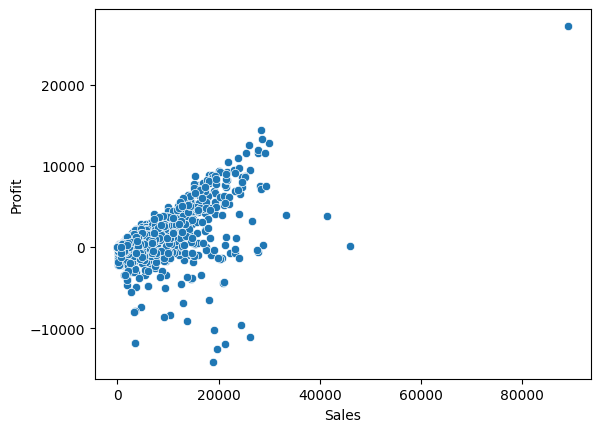

In [ ]:
sns.scatterplot(df,x=df['Sales'],y=df['Profit'])

<Axes: xlabel='Sales', ylabel='Sales per Unit'>

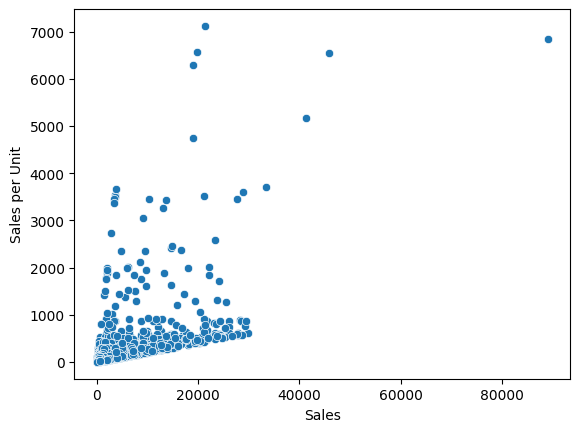

In [ ]:
sns.scatterplot(df,x=df['Sales'],y=df['Sales per Unit'])

<Axes: xlabel='Sales per Unit', ylabel='Unit Price'>

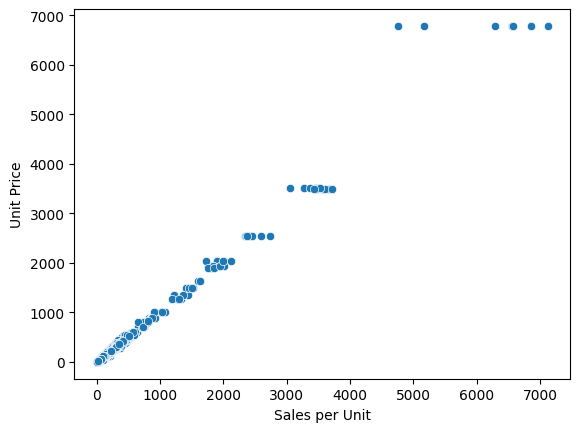

In [ ]:
sns.scatterplot(df,x=df['Sales per Unit'],y =df['Unit Price'])

<Axes: xlabel='Customer Age', ylabel='Profit Margin'>

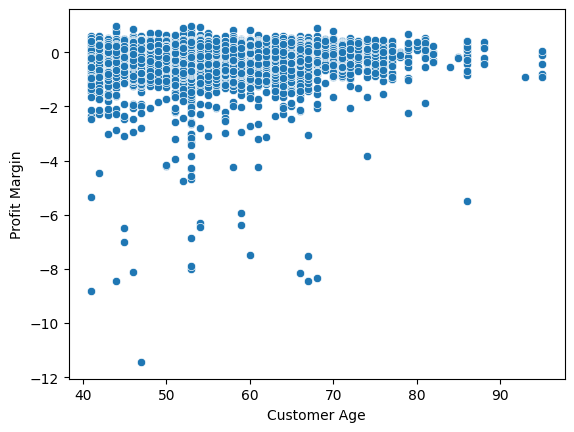

In [ ]:
sns.scatterplot(df,x=df['Customer Age'],y=df['Profit Margin'])

<Axes: xlabel='Profit per Unit', ylabel='Sales per Unit'>

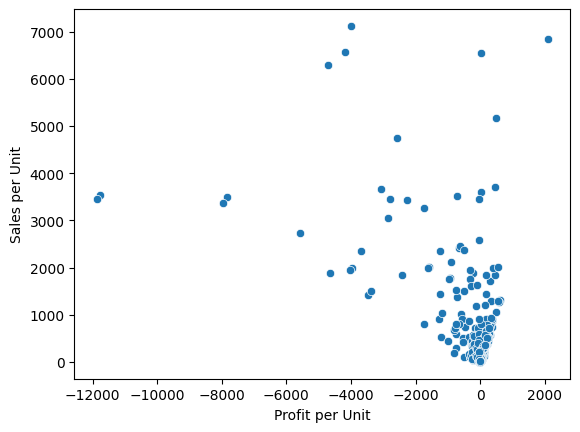

In [ ]:
sns.scatterplot(df,x=df['Profit per Unit'],y=df['Sales per Unit'])

# Detailed Analysis regarding discount

In [ ]:
df['Discount'].describe()

,Discount
count,8399.000000
mean,0.049652
std,0.031830
min,0.000000
25%,0.020004
50%,0.049988
75%,0.080017
max,0.250000


In [ ]:
df['Discount'].value_counts().sort_index()

,count
Discount,
0.000000,756
0.010002,806
0.020004,765
0.029999,779
0.040009,770
0.049988,786
0.059998,734
0.070007,710
0.080017,765


In [ ]:
df['Discount %'] = (df['Discount'] * 100).round().astype('int8')

In [ ]:
dis_sum = df.groupby('Discount %').agg(
    Records = ('Discount', 'size'),
    Total_Sales = ('Sales','sum'),
    Avg_Sales = ('Sales', 'mean'),
    Total_Profit = ('Profit','sum'),
    Avg_Profit = ('Profit','mean'),
    Orders = ('Order ID','nunique'),
    Quantity = ('Order Quantity','sum'),
    Shipping_Cost = ('Shipping Cost','sum')
)

dis_sum['Profit Margin'] = dis_sum['Total_Profit']/dis_sum['Total_Sales']
dis_sum['Shipping Cost %'] = (dis_sum['Shipping_Cost']/dis_sum['Total_Sales'])*100

display(dis_sum)

,Records,Total_Sales,Avg_Sales,Total_Profit,Avg_Profit,Orders,Quantity,Shipping_Cost,Profit Margin,Shipping Cost %
Discount %,,,,,,,,,,
0,756,1.493748e+06,1975.857422,188188.781250,248.926956,735,19736,9672.620117,0.125984,0.647540
1,806,1.487746e+06,1845.838135,169252.750000,209.991013,779,20801,10605.700195,0.113765,0.712871
2,765,1.362555e+06,1781.117188,179453.265625,234.579437,715,19311,9977.919922,0.131704,0.732295
3,779,1.335275e+06,1714.088257,222349.031250,285.428802,745,20201,9329.240234,0.166519,0.698676
4,770,1.379479e+06,1791.531616,117639.460938,152.778519,733,19777,10082.250000,0.085278,0.730874
5,786,1.367723e+06,1740.105103,139488.890625,177.466782,756,20001,10430.330078,0.101986,0.762606
6,734,1.303603e+06,1776.025757,84837.632812,115.582603,691,17623,9135.500000,0.065079,0.700789
7,710,1.350269e+06,1901.786987,119457.921875,168.250595,684,18711,9580.099609,0.088470,0.709496
8,765,1.329173e+06,1737.481201,113032.148438,147.754440,736,20255,10075.830078,0.085039,0.758052


In [ ]:
com_dis = dis_sum.loc[0:10]

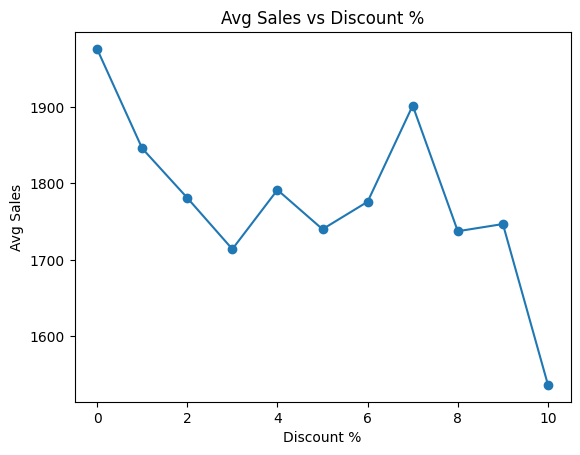

In [ ]:
plt.plot(
    com_dis.index,
    com_dis['Avg_Sales'],
    marker = 'o'
)

plt.xlabel('Discount %')
plt.ylabel('Avg Sales')
plt.title('Avg Sales vs Discount %')
plt.show()

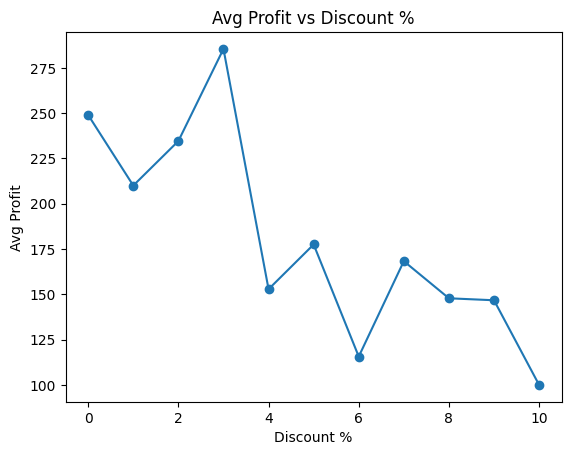

In [ ]:
plt.plot(
    com_dis.index,
    com_dis['Avg_Profit'],
    marker = 'o'
)

plt.xlabel('Discount %')
plt.ylabel('Avg Profit')
plt.title('Avg Profit vs Discount %')
plt.show()

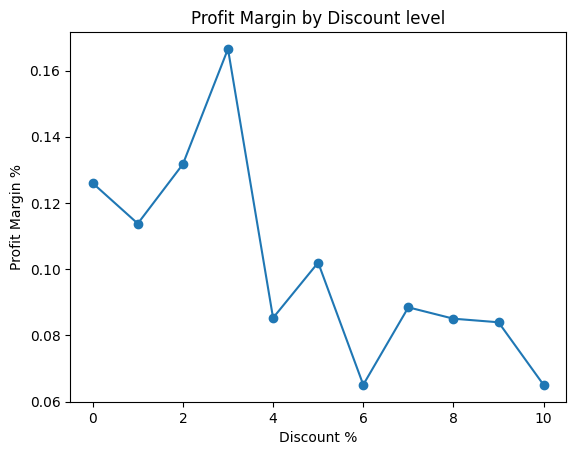

In [ ]:
plt.plot(
    com_dis.index,
    com_dis['Profit Margin'],
    marker = 'o'
)

plt.xlabel('Discount %')
plt.ylabel('Profit Margin %')
plt.title('Profit Margin by Discount level')
plt.show()

In [ ]:
df[df["Discount %"] == 3].groupby("Product Category").agg(
    Avg_Sales=("Sales", "mean"),
    Avg_Profit=("Profit", "mean"),
    Count=("Sales", "size")
)

/tmp/ipykernel_3153/1000144896.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["Discount %"] == 3].groupby("Product Category").agg(


,Avg_Sales,Avg_Profit,Count
Product Category,,,
Furniture,2914.691406,288.814697,161
Office Supplies,922.448364,185.365768,447
Technology,2653.070068,543.809143,171


# Correlation Analysis between Sales and Profit

In [ ]:
df['Sales'].corr(df['Profit'])

np.float64(0.5819602727345012)

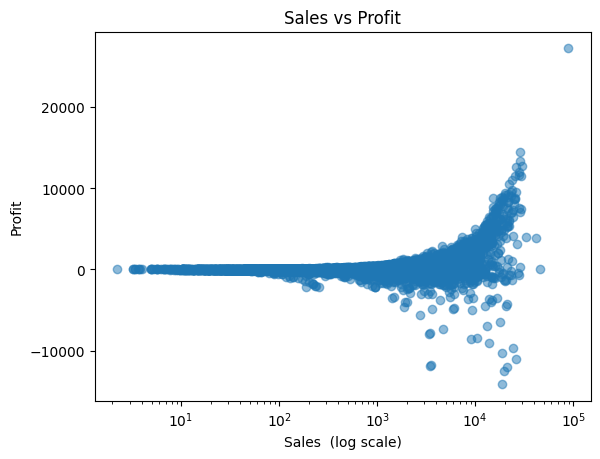

In [ ]:
plt.scatter(df['Sales'],df['Profit'],alpha=0.5)
plt.xscale('log')
plt.xlabel('Sales  (log scale)')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.show()

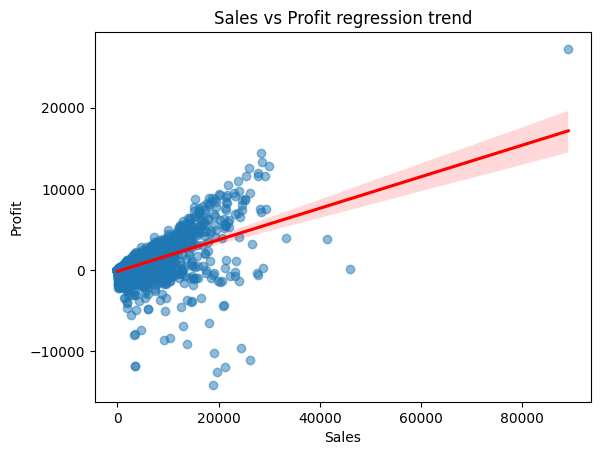

In [ ]:
sns.regplot(

    df,
    x='Sales',
    y='Profit',
    scatter_kws = {'alpha': 0.5},
    line_kws = {'color': 'red'}
)


plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit regression trend')
plt.show()


In [ ]:
sales_75 = df['Sales'].quantile(0.75)

hslp = df[(df['Sales'] >= sales_75) & (df['Profit'] <= 0)]

hslp

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,City,Customer Age,Customer Name,Customer Segment,Discount,Number of Records,Order Date,Order ID,Order Priority,Order Quantity,...,Order Month,Order Day,Order Quarter,Order Day of Week,delivery speed,Profit Margin,Profit per Unit,Sales per Unit,Shipping Cost %,Discount %
4,Napa,53,Alan Schoenberger,Corporate,0.070007,1,2012-01-02,37537,Low,43,...,1,2,1,Monday,normal,-0.257080,-24.421875,94.9375,1.102539,7
21,Bedford,53,Darren Budd,Consumer,0.070007,1,2012-01-05,57253,Critical,48,...,1,5,1,Thursday,instant,-0.026535,-6.984375,263.2500,0.277100,7
35,Fort Dodge,53,Matt Collins,Consumer,0.010002,1,2012-01-05,1028,High,11,...,1,5,1,Thursday,normal,-0.029877,-5.488281,183.7500,0.296387,1
36,Bristol,53,Corey Roper,Small Business,0.020004,1,2012-01-06,48226,Low,23,...,1,6,1,Friday,instant,-0.046143,-4.730469,102.5000,1.520508,2
37,Galesburg,53,Julia West,Home Office,0.040009,1,2012-01-06,23488,Critical,30,...,1,6,1,Friday,fast,-0.422852,-368.500000,871.0000,0.170532,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8350,Lynchburg,81,Lisa DeCherney,Corporate,0.070007,1,2015-12-20,54791,High,42,...,12,20,4,Sunday,normal,-0.208740,-21.234375,101.7500,0.818848,7
8362,Lewiston,85,Ann Blume,Corporate,0.010002,1,2015-12-23,7751,Not Specified,45,...,12,23,4,Wednesday,fast,-0.168945,-17.062500,101.0625,1.279297,1
8364,Deer Park,86,Anthony Witt,Corporate,0.059998,1,2015-12-24,44992,Critical,32,...,12,24,4,Thursday,normal,-0.075378,-16.750000,222.2500,0.979492,6
8372,Ann Arbor,86,Giulietta Weimer,Corporate,0.000000,1,2015-12-25,12129,Medium,36,...,12,25,4,Friday,normal,-0.246826,-33.281250,134.7500,1.447266,0


In [ ]:
hslp[[
    "Sales",
    "Profit",
    "Discount %",
    "Shipping Cost",
    "Order Quantity",
    "Product Category",
    "Product Sub-Category",
    "Region"
]].sort_values("Sales", ascending=False)

,Sales,Profit,Discount %,Shipping Cost,Order Quantity,Product Category,Product Sub-Category,Region
3145,27875.539062,-635.690002,0,24.490000,46,Technology,Copiers and Fax,Central
4357,27663.919922,-391.920013,5,24.490000,8,Technology,Copiers and Fax,Central
37,26133.390625,-11053.599609,4,44.549999,30,Furniture,Bookcases,Central
8317,24391.160156,-9611.910156,4,44.549999,28,Furniture,Bookcases,East
3610,23949.509766,-1312.839966,0,24.490000,46,Technology,Copiers and Fax,West
...,...,...,...,...,...,...,...,...
4539,1731.104004,-270.573730,1,69.000000,18,Furniture,Tables,East
3068,1727.790039,-694.900024,10,36.610001,32,Furniture,Bookcases,East
8148,1722.650024,-399.670013,5,51.419998,15,Furniture,Bookcases,East
3845,1718.430054,-192.492004,0,66.669998,6,Furniture,Tables,Central


# Understanding why loss occurs

In [ ]:
df['Profit Status'] = np.where(df['Profit'] > 0, 'Profit', 'Loss/Break-even')

df.groupby('Profit Status').agg(
    avg_sales = ('Sales', 'mean'),
    avg_profit = ('Profit', 'mean'),
    avg_discount = ('Discount', 'mean'),
    avg_shipping_cost = ('Shipping Cost', 'mean'),
    avg_quantity = ('Order Quantity', 'mean'),
    count = ('Profit', 'size'),
    orders = ('Order ID','nunique')
)

,avg_sales,avg_profit,avg_discount,avg_shipping_cost,avg_quantity,count,orders
Profit Status,,,,,,,
Loss/Break-even,995.798523,-258.560638,0.051907,15.360221,21.864447,4264,3427
Profit,2580.294189,634.648254,0.047371,10.238225,29.394680,4135,3359


In [ ]:
df.groupby('Product Category').agg(
    avg_sales = ('Sales', 'mean'),
    avg_profit = ('Profit', 'mean'),
    total_sales = ('Sales', 'sum'),
    total_profit = ('Profit', 'sum'),
    count = ('Profit', 'size'),
    orders = ('Order ID','nunique')
)


/tmp/ipykernel_3153/3665859895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Product Category').agg(


,avg_sales,avg_profit,total_sales,total_profit,count,orders
Product Category,,,,,,
Furniture,3003.822754,68.116577,5178590.5,117432.984375,1724,1561
Office Supplies,814.048157,112.369080,3752762.0,518021.468750,4610,3632
Technology,2897.940918,429.207520,5984248.0,886313.500000,2065,1858


Text(0, 0.5, 'Profit')

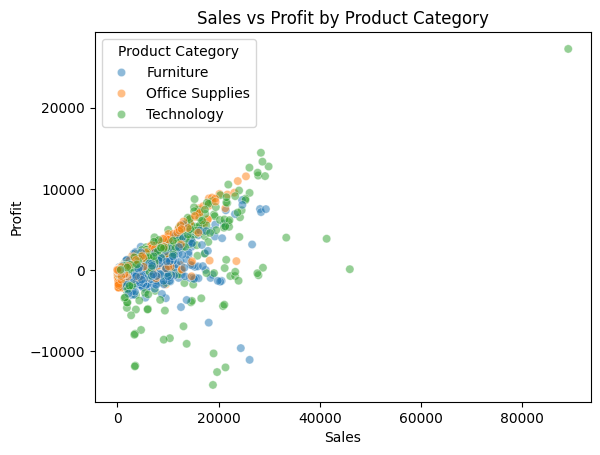

In [ ]:
sns.scatterplot(
    df,
    x='Sales',
    y='Profit',
    hue='Product Category',
    alpha = 0.5,
)
plt.title('Sales vs Profit by Product Category')
plt.xlabel('Sales')
plt.ylabel('Profit')

In [ ]:
subcat_sum = df.groupby(df['Product Sub-Category']).agg(
    sales = ('Sales','sum'),
    profit = ('Profit','sum')
)

subcat_sum['profit margin'] = subcat_sum['profit']/subcat_sum['sales']*100

subcat_sum.sort_values('profit',ascending=False)

/tmp/ipykernel_3153/1892156489.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcat_sum = df.groupby(df['Product Sub-Category']).agg(


,sales,profit,profit margin
Product Sub-Category,,,
Telephones and Communication,1.889314e+06,316951.656250,16.776020
Office Machines,2.168697e+06,307712.937500,14.188838
Binders and Binder Accessories,1.022958e+06,307413.406250,30.051434
Copiers and Fax,1.130361e+06,167361.468750,14.806016
Chairs & Chairmats,1.761836e+06,149649.718750,8.493962
Office Furnishings,6.980938e+05,100427.921875,14.386021
Appliances,7.369916e+05,97158.062500,13.183064
Computer Peripherals,7.958759e+05,94287.476562,11.847007
Envelopes,1.740858e+05,48182.601562,27.677504


In [ ]:
df.groupby('Product Category')['Profit'].agg(
    ['count','mean','median','std']
)

/tmp/ipykernel_3153/3703591103.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Product Category')['Profit'].agg(


,count,mean,median,std
Product Category,,,,
Furniture,1724,68.116577,-14.250000,1112.923218
Office Supplies,4610,112.369080,-3.845000,744.617920
Technology,2065,429.207520,66.220001,1863.208252


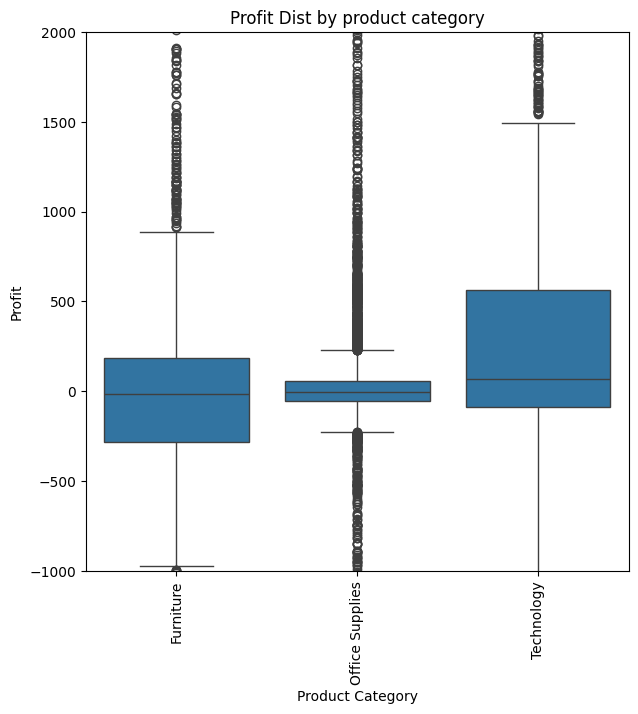

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(
    df,
    x='Product Category',
    y='Profit'
)

plt.ylim(-1000,2000)
plt.xticks(rotation=90)
plt.title('Profit Dist by product category')
plt.show()

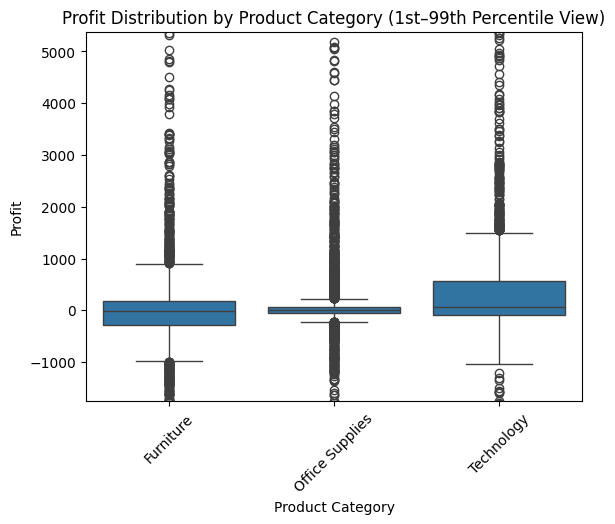

In [ ]:
lower = df["Profit"].quantile(0.01)
upper = df["Profit"].quantile(0.99)

sns.boxplot(
    data=df,
    x="Product Category",
    y="Profit"
)

plt.ylim(lower, upper)
plt.xticks(rotation=45)
plt.title("Profit Distribution by Product Category (1st–99th Percentile View)")
plt.show()

#Statistical Analysis

In [ ]:
groups = [
    group['Profit'].dropna().values
    for _, group in df.groupby('Product Category')
]

stat, p = levene(*groups)
print(f'levene stat: {stat}')
print(f'p-value: {p}')
#

levene stat: 201.31469713742683
p-value: 3.9974664895134626e-86


/tmp/ipykernel_3153/1619393049.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby('Product Category')


# Kruskal-Wallis Test

In [ ]:
stat, p = kruskal(*groups)

print(f'kruskal stat: {stat}')
print(f'p-value: {p}')

kruskal stat: 175.02210936445505
p-value: 9.872606923323758e-39


# Dunn's Post-Hoc Test

In [ ]:
!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp

In [ ]:
dunn_results = sp.posthoc_dunn(
    df,
    val_col = 'Profit',
    group_col = 'Product Category',
    p_adjust = 'bonferroni'
)

print(dunn_results)

                    Furniture  Office Supplies    Technology
Furniture        1.000000e+00     8.987886e-07  1.749885e-36
Office Supplies  8.987886e-07     1.000000e+00  6.903019e-24
Technology       1.749885e-36     6.903019e-24  1.000000e+00


# Profitability Analysis

In [ ]:
df.groupby('Customer Segment')['Profit'].agg(
    ['count','mean','median','std']
)

/tmp/ipykernel_3153/3832267151.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Customer Segment')['Profit'].agg(


,count,mean,median,std
Customer Segment,,,,
Consumer,1649,174.627045,0.260,1370.392578
Corporate,3076,194.975922,-2.841,1224.120239
Home Office,2032,156.670319,-0.430,1054.269165
Small Business,1642,192.270386,-0.725,1121.383423


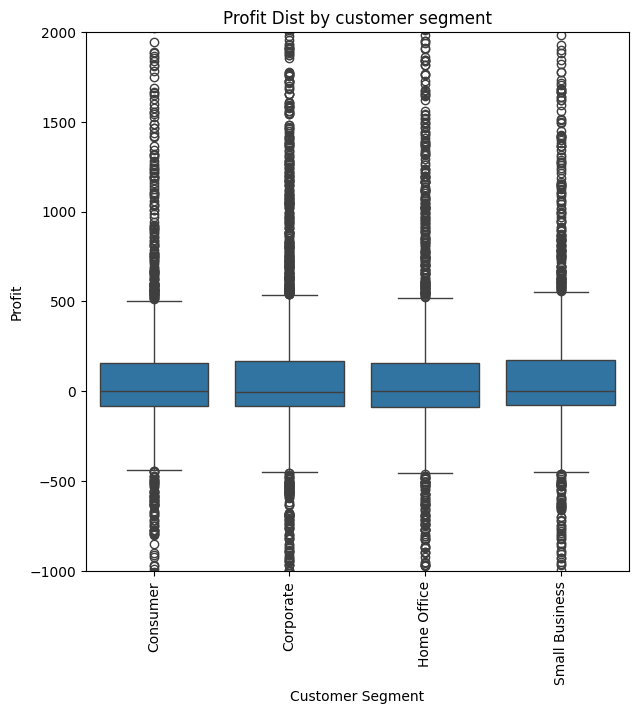

In [ ]:
plt.figure(figsize=(7,7))
sns.boxplot(
    df,
    x='Customer Segment',
    y='Profit'
)

plt.ylim(-1000,2000)
plt.xticks(rotation=90)
plt.title('Profit Dist by customer segment')
plt.show()

# One Way ANOVA

In [ ]:
segment_groups = [
    group['Profit'].dropna().values
    for _, group in df.groupby('Customer Segment')
]

stat, p = levene(*segment_groups)
print(f'levene stat: {stat}')
print(f'p-value: {p}')


levene stat: 0.6419443535244079
p-value: 0.5879645497958288


/tmp/ipykernel_3153/495376544.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby('Customer Segment')


In [ ]:
f_stat, p_value = f_oneway(*segment_groups)

print(f'f_stat: {f_stat}')
print(f'p_value: {p_value}')

f_stat: 0.48383060097694397
p_value: 0.6935194730758667


In [ ]:
df.groupby('Ship Mode')['days taken'].agg(
    ['count','mean','median','std']
)


,count,mean,median,std
Ship Mode,,,,
Delivery Truck,1146,2.035777,2.0,1.792642
Express Air,983,2.005086,2.0,1.929241
Regular Air,6270,2.035566,2.0,2.434108


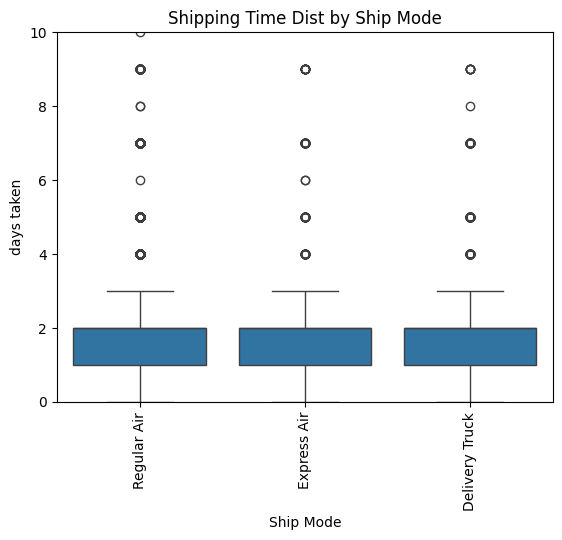

In [ ]:
sns.boxplot(
    df,
    x='Ship Mode',
    y='days taken',

)

plt.ylim(0,10)
plt.xticks(rotation=90)
plt.title('Shipping Time Dist by Ship Mode')
plt.show()

In [ ]:
mode_groups = [
    group['days taken'].dropna().values
    for _, group in df.groupby('Ship Mode')
]

stat, p = levene(*mode_groups)
print(f'levene stat: {stat}')
print(f'p-value: {p}')

levene stat: 0.18915130392609739
p-value: 0.8276647956689298


In [ ]:
f_stat, p_value = f_oneway(*mode_groups)

print(f'f_stat: {f_stat}')
print(f'p_value: {p_value}')

f_stat: 0.0762725190583792
p_value: 0.9265643078905359


# Additional Analysis

In [ ]:
df.groupby(['Region','Profit Status'])['Profit Status'].count().unstack()

Profit Status,Loss/Break-even,Profit
Region,,
Central,1348,1362
East,995,900
South,909,929
West,1012,944


In [ ]:
df.groupby(['Product Category','Profit Status'])['Profit Status'].count().unstack()

/tmp/ipykernel_3153/125016036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Product Category','Profit Status'])['Profit Status'].count().unstack()


Profit Status,Loss/Break-even,Profit
Product Category,,
Furniture,922,802
Office Supplies,2461,2149
Technology,881,1184


In [ ]:
df.groupby('Profit Status').agg(
    count = ('Profit', 'size'),
    avg_sales = ('Sales', 'mean'),
    median_sales = ('Sales','median'),
    avg_discount = ('Discount', 'mean'),
    avg_shipping_cost = ('Shipping Cost', 'mean'),
    avg_order_quan = ('Order Quantity', 'mean'),
    avg_prod_mar = ('Product Base Margin','mean')
)

,count,avg_sales,median_sales,avg_discount,avg_shipping_cost,avg_order_quan,avg_prod_mar
Profit Status,,,,,,,
Loss/Break-even,4264,995.798523,241.119995,0.051907,15.360221,21.864447,0.539857
Profit,4135,2580.294189,964.090027,0.047371,10.238225,29.394680,0.484393


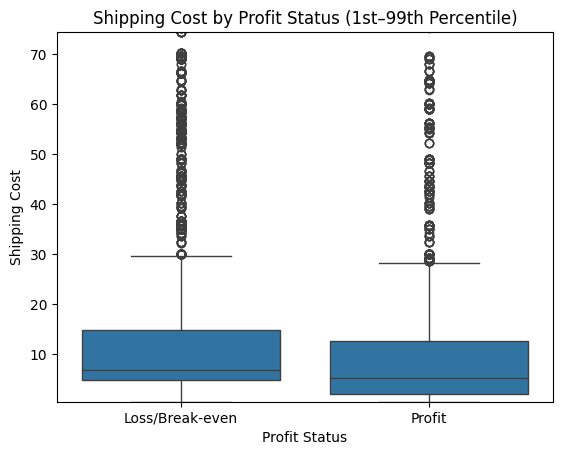

In [ ]:
lower = df["Shipping Cost"].quantile(0.01)
upper = df["Shipping Cost"].quantile(0.99)

sns.boxplot(
    data=df,
    x="Profit Status",
    y="Shipping Cost"
)

plt.ylim(lower, upper)
plt.title("Shipping Cost by Profit Status (1st–99th Percentile)")
plt.show()

In [ ]:
df["Shipping Cost % of Sales"] = (
    df["Shipping Cost"] / df["Sales"]
) * 100
df['Shipping Cost % of Sales']

,Shipping Cost % of Sales
0,2.600355
1,4.011554
2,3.938469
3,0.320429
4,1.102080
...,...
8394,1.006472
8395,1.642974
8396,4.946997
8397,3.048560


In [ ]:
df.groupby('Profit Status')['Shipping Cost % of Sales'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
Profit Status,,,,
Loss/Break-even,4264,5.506505,2.845695,8.113957
Profit,4135,1.035277,0.587961,1.983293


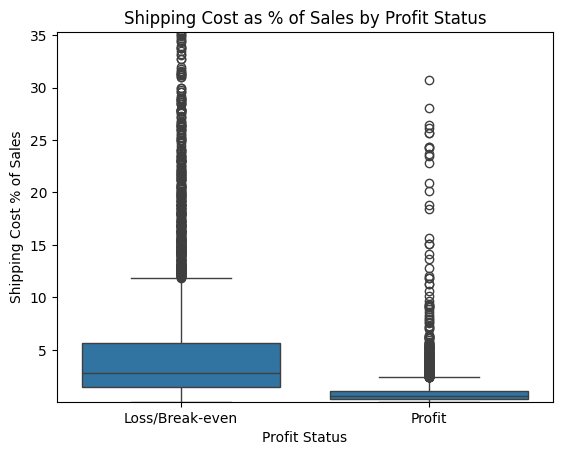

In [ ]:
lower = df["Shipping Cost % of Sales"].quantile(0.01)
upper = df["Shipping Cost % of Sales"].quantile(0.99)

sns.boxplot(
    data=df,
    x="Profit Status",
    y="Shipping Cost % of Sales"
)

plt.ylim(lower, upper)
plt.title("Shipping Cost as % of Sales by Profit Status")
plt.show()

In [ ]:
df['Sales Band'] = pd.qcut(
    df['Sales'],
    q = 4,
    labels = ['Low','Medium','Medium-High','High']
)

In [ ]:
sales_status = pd.crosstab(
    df['Sales Band'],
    df['Profit Status'],
    normalize = 'index'
) * 100

sales_status


Profit Status,Loss/Break-even,Profit
Sales Band,,
Low,68.571429,31.428571
Medium,64.380952,35.619048
Medium-High,41.972368,58.027632
High,28.142857,71.857143


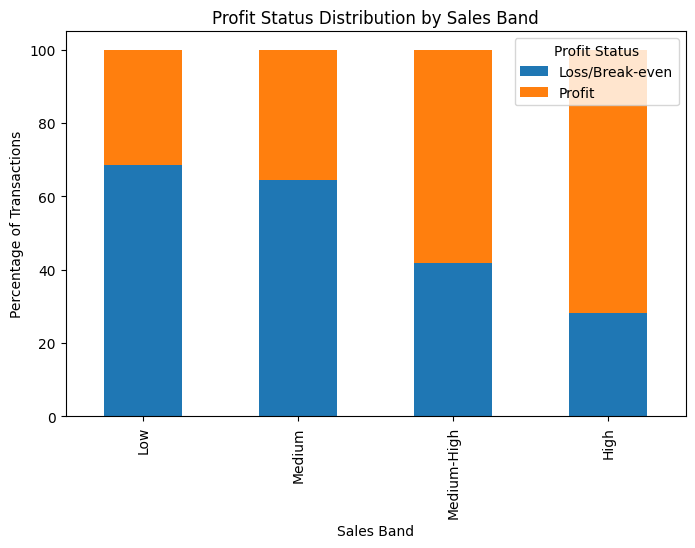

In [ ]:
sales_status.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel("Percentage of Transactions")
plt.title("Profit Status Distribution by Sales Band")
plt.show()

In [ ]:
df.groupby(['Profit Status', 'Product Sub-Category'])['Profit Status'].count().unstack()

/tmp/ipykernel_3153/3120833985.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Profit Status', 'Product Sub-Category'])['Profit Status'].count().unstack()


Product Sub-Category,Appliances,Binders and Binder Accessories,Bookcases,Chairs & Chairmats,Computer Peripherals,Copiers and Fax,Envelopes,Labels,Office Furnishings,Office Machines,Paper,Pens & Art Supplies,Rubber Bands,"Scissors, Rulers and Trimmers",Storage & Organization,Tables,Telephones and Communication
Profit Status,,,,,,,,,,,,,,,,,
Loss/Break-even,213,525,148,202,408,35,72,33,314,128,727,302,100,110,379,258,310
Profit,221,390,41,184,350,52,174,255,474,209,498,331,79,34,167,103,573


# Key Findings

### Data Quality and Feature Engineering
- Missing values in `Product Base Margin` and `Customer Age` were treated using median imputation.
- Multiple derived features were created, including delivery duration, temporal variables, profit margin, profit per unit, and shipping cost as a percentage of sales.

### Discount Impact
- Moderate discount levels were associated with improved sales performance.
- Higher discounts were associated with declining profit margins, suggesting excessive discounting may negatively affect profitability.

### Product Category Profitability
- Profit distributions differed significantly across product categories.
- Technology showed the highest average profitability, while Furniture performed comparatively poorly.
- Kruskal-Wallis and Dunn's post-hoc tests confirmed statistically significant differences between the categories.

### Loss-Making Transactions
- Loss-making and break-even transactions had lower average sales and higher shipping costs relative to sales.
- Shipping Cost % emerged as an important characteristic associated with unprofitable transactions.

### Customer Segments and Shipping
- ANOVA found no statistically significant difference in average profit across customer segments.
- Ship Mode also showed no statistically significant difference in delivery duration.